# Brightfield Reconstruction of a “Potato” Object

This notebook is a **concise, code-focused companion** to the
[**Base Brightfield Notebook (Gaussian Blobs)**](./1.Brightfield_base_notebook.ipynb).
Here, we reuse the same tomographic reconstruction pipeline but swap the test object for a
precomputed **“potato”** volume from `test_data/`. Explanations are brief; the emphasis is on **running the workflow** and **visualizing results**.

We follow the same strategy as the base notebook:
- Use a **Brightfield imaging model** to generate forward projections from the rotating 3D object.
- Initialize rotations (via VAE in the base pipeline) and then run **gradient-based optimization** to refine both the **3D volume** and the **rotation parameters**.

If you need the full theoretical background (tomography, VAE initialization, loss terms, and optimization details), **please see the base notebook**.

---

### Notebook Outline

1. **Load the Potato Volume**  
   Import `test_data/potato.npy`, normalize, and preview central slices.

2. **Set Up Brightfield Imaging Model**  
   Configure optics and build the Brightfield imaging model used for forward projections.

3. **Generate Projections**  
   Simulate 2D projections under an oscillatory rotation pattern (same as in the base notebook).

4. **Reconstruct the 3D Volume**  
   Run the Tomography model to jointly refine the volume and rotation parameters.

5. **Evaluate & Visualize**  
   Inspect reconstructed slices and forward projections; compare to ground truth frames.

6. **Save Results**  
   Export the reconstructed volume and recovered quaternions for downstream analysis.

> **Note:** Aside from changing the input volume to the “potato” object, the pipeline mirrors the base notebook so results are directly comparable.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SkariZ/TomoDpDt/blob/main/Notebooks/sum_projection_vobble.ipynb)



In [1]:
# Uncomment if you run this notebook in Google Colab
#!pip install deeplay deeptrack plotly scipy opencv-python
#!git clone https://github.com/SkariZ/TomoDpDt.git
#import sys
#sys.path.append('/content/TomoDpDt')

In [2]:
# Uncomment if running this notebook locally
#import sys
#sys.path.append('..')

In [3]:
import sys
sys.path.append('..')

import tomodpdt

import numpy as np
import time

import deeplay as dl
import torch
from torch.utils.data import DataLoader

In [4]:
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEV)

[suppressed training logs: 19 chars]


## 1. Load 3D Volume

In this example, we load a **3D volume of a potato-like object**, which serves as a simple synthetic test sample.  
The volume mimics a structure with **localized regions of higher refractive index**, similar to how real biological or soft-matter samples may contain internal inhomogeneities.  

This object is precomputed and stored in the `test_data/` folder, allowing for direct use without additional generation steps.


In [5]:
volume = np.load('../test_data/vol_potato1.npy')

In [6]:
print(f"Shape of the volume: {volume.shape}")

Shape of the volume: (64, 64, 64)


The volume has refractive index values in the range 1.33-1.42.

In [7]:
volume.max(), volume.min(), volume.mean(), volume.std()

(1.4200001, 1.33, 1.3315866, 0.0052548475)

For optimization purposes it easier to work with the refractive index difference, assuming the sample is in water we can subtract 1.33.

In [8]:
volume = volume - 1.33

The 3D volume is stored in a `numpy` array and can be interactively visualized using the `ipyvolume` library together with `plotly`. Having it interactive and saving the `.ipynb` however make the file extremely large. Uncomment the code below for interactive plot.

In [9]:
# tomodpdt.plotting.visualize_3d_volume(volume)

Using sum projections along the x, y, and z axes, we can visualize the structure of the volume.

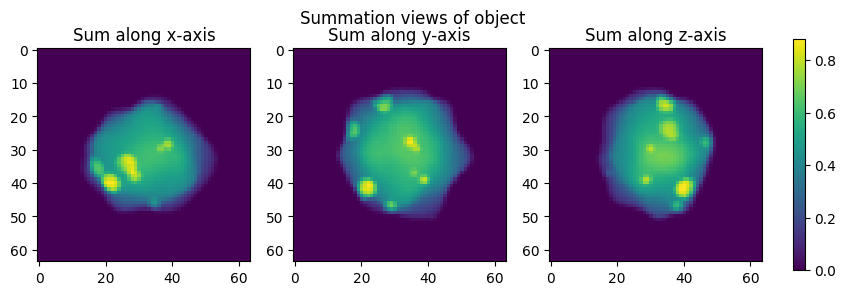

In [10]:
tomodpdt.plotting.plot_sum_object(volume)

## 2. Set Up Brightfield Imaging Model

In [11]:
from tomodpdt.imaging_modality_torch import setup_optics, imaging_model

# --- Setup the optical system ---
optics_settings = setup_optics(
    shape=volume.shape,       # Shape of the 3D volume
    padding_xy=volume.shape[0]//2,  # Padding in the lateral directions (avoids wrap-around effects)
    microscopy_regime='Brightfield', # Choose microscopy type: 'Brightfield', 'Fluorescence', etc.
    NA=1.1,                      # Numerical Aperture of the objective
    wavelength=520e-9,           # Illumination wavelength in meters
    resolution=200e-9,           # Effective pixel resolution in meters
    magnification=1,             # System magnification
    return_field=True            # Return the complex optical field instead of intensity only
)

# --- Build the imaging model ---
brightfield_model = imaging_model(optics_setup=optics_settings)


## 3. Generate Projections

In [12]:
test_object, q_gt, projections, imaging_model = tomodpdt.simulate.create_data(
    volume=volume, # The volume we want to reconstruct
    image_modality=brightfield_model, # We use our brightfield imaging model
    rotation_case='random_sinusoidal', # We rotate the object around 1 main axis, but the other 2 axes are also non-zero an
    samples=250, # Number of projections
    duration=2 # Duration is the number of full revolutions
    )

[suppressed training logs: 20 chars]


### 3.2 Visualizing the Training Data

In this section, we explore the generated training data through the forward images and the corresponding rotation parameters.

#### Vizualising the forward projections

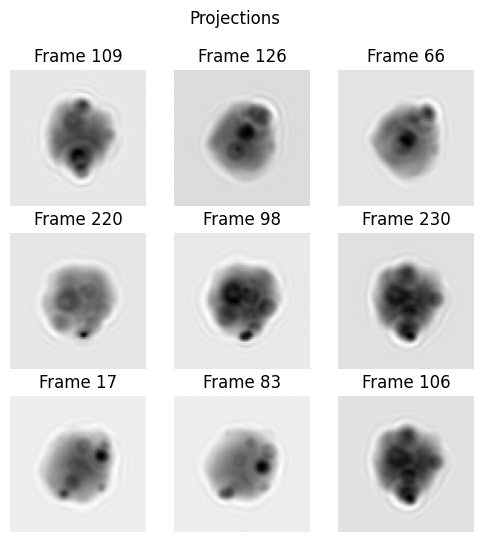

In [13]:
tomodpdt.plotting.plot_grid33_frames(projections, title="Projections", randomize=True)

#### Visualizing the Quaternion Trajectory

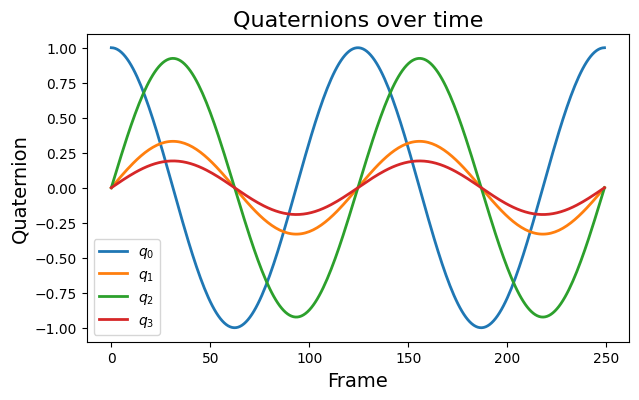

In [14]:
tomodpdt.plotting.plot_quaternions(q_gt)

## 4. Reconstruct the 3D Volume

In this section, we focus on **tomographic reconstruction**, that is, the process of recovering a 3D volume from a set of 2D projection images acquired under different viewing angles.

#### Create the tomographic model

In [15]:
tomographic_model = tomodpdt.Tomography(
    volume_size=volume.shape, # The size of the volume
    initial_volume='zeros', # 'refraction' since we are optimizing the refractive index
    rotation_optim_case='basis', # 'basis' or 'quaternion', 'basis' is smoother
    imaging_model=brightfield_model, # The imaging model
    )

#### Initialize the parameters

In [16]:
tomographic_model.initialize_parameters(projections, normalize=False, max_epochs=200)

[suppressed training logs: 1,784 chars]
---------------------------------------------------------------------
---------------------------------------------------------------------
170 K     Trainable params
0         Non-trainable params
170 K     Total params
0.682     Total estimated model params size (MB)
77        Modules in train mode
0         Modules in eval mode


[suppressed training logs: 618 chars]
c:\Users\Fredrik\miniconda3\envs\deeplaydev\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


[suppressed training logs: 225 chars]


✅ Rotation initialization from latent space successful.


For vizualisation we initialize a `TomoPlotter` class for easier plotting.

In [17]:
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

#### Visualizing the Latent Space Trajectory, Peaks and the Initial Guess


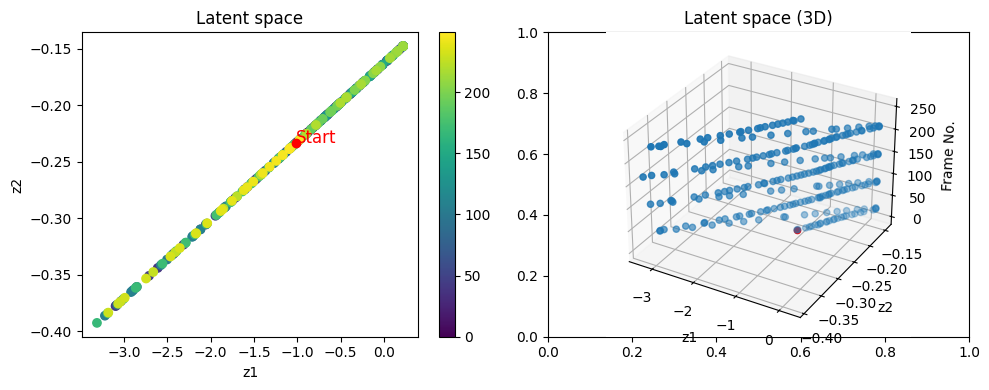

In [18]:
plotter.plot_latent_space()

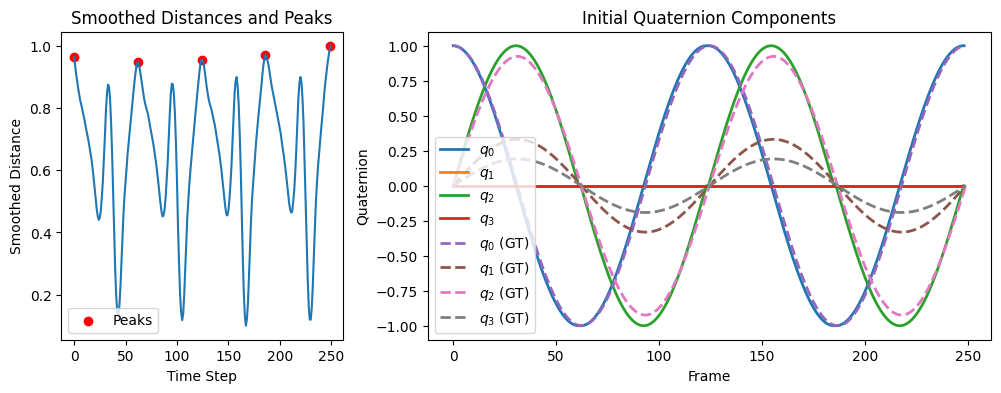

In [19]:
plotter.plot_smooth_dist_intial_guess(q_gt=q_gt)

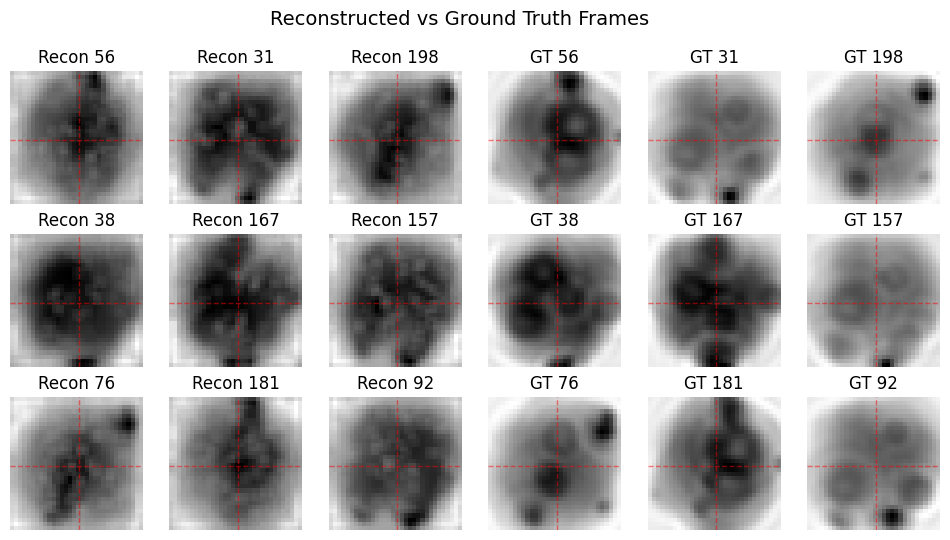

In [20]:
plotter.plot_reconstructed_vs_gt()


### 4.1 Start the 3D Reconstruction Optimization


In [21]:
N1 = len(tomographic_model.frames) # Number of frames
idx = torch.arange(N1) # List of indexes
epochs_object_only = 50 # Number of epochs for the object only optimization
batch_size_object_only = 32 # Batch size for the object only optimization

In [22]:
# Toggle the gradients of the quaternion parameters to False
tomographic_model.toggle_gradients_quaternion(False)

# Toggle the gradients of the translation parameters to False
tomographic_model.toggle_gradients_translation(False)

# Move the model to device and all parameters
tomographic_model.move_all_to_device(DEV)

[suppressed training logs: 926 chars]
-----------------------------------------------------------------
-----------------------------------------------------------------
262 K     Trainable params
171 K     Non-trainable params
433 K     Total params
1.734     Total estimated model params size (MB)
83        Modules in train mode
0         Modules in eval mode


[suppressed training logs: 294 chars]


[suppressed training logs: 225 chars]


[suppressed training logs: 45 chars]


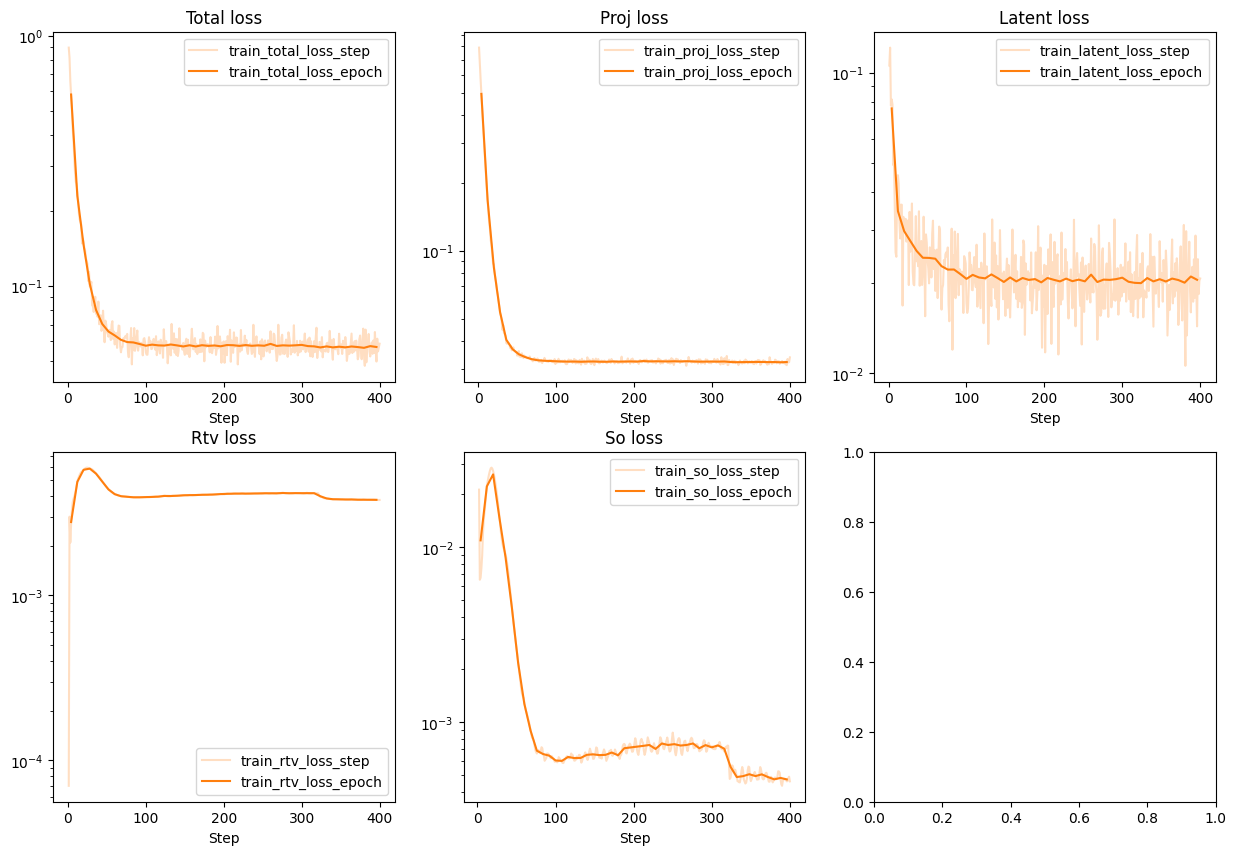

In [23]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_only, accelerator="auto", log_every_n_steps=10)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_only , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

### 4.2 Optimize the 3D volume and the rotation parameters

In [24]:
epochs_object_rot = 250 # Number of epochs for the object and rotation optimization
batch_size_object_rot = 32 # Batch size for the object and rotation optimization

In [25]:
# Toggle the gradients of the quaternion parameters
tomographic_model.toggle_gradients_quaternion(True)

# The gradients of the translation parameters are already False and remain so since we do not want to optimize them now
# tomographic_model.toggle_gradients_translation(False)

# Move the model to device
tomographic_model.move_all_to_device(DEV)

and train the model for `epochs_object_rot` epochs...

[suppressed training logs: 926 chars]
-----------------------------------------------------------------
-----------------------------------------------------------------
262 K     Trainable params
171 K     Non-trainable params
433 K     Total params
1.734     Total estimated model params size (MB)
83        Modules in train mode
0         Modules in eval mode


[suppressed training logs: 225 chars]


[suppressed training logs: 45 chars]


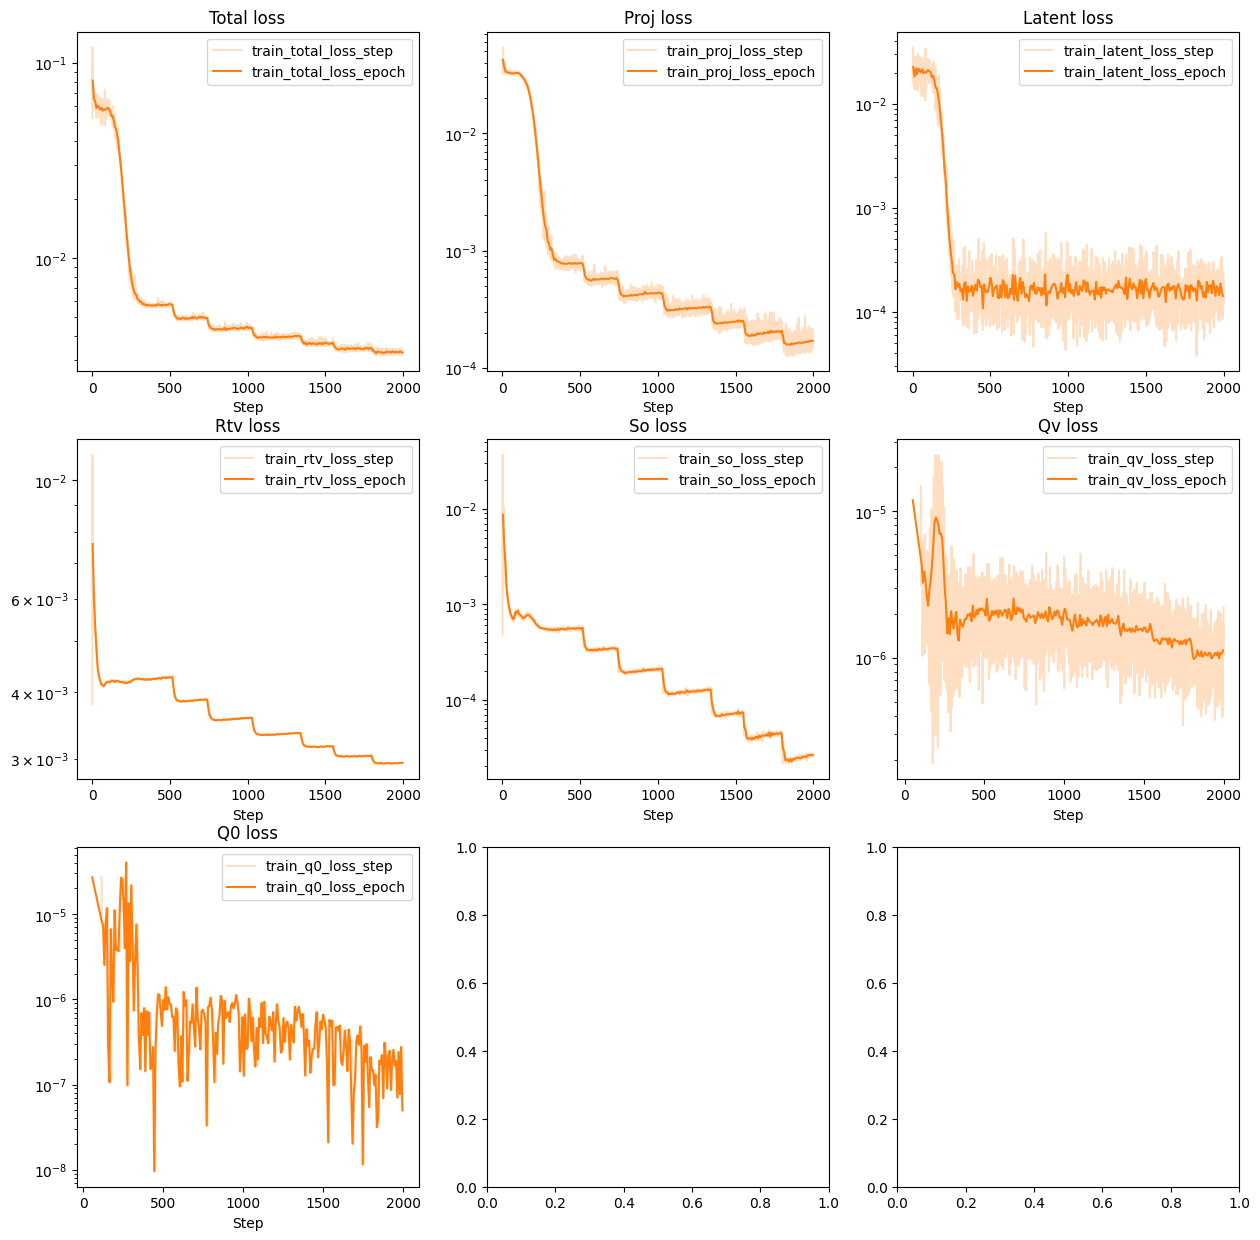

In [26]:
# Train the model
start_time = time.time()
trainer = dl.Trainer(max_epochs=epochs_object_rot, accelerator="auto", log_every_n_steps=None)
trainer.fit(tomographic_model, DataLoader(idx, batch_size=batch_size_object_rot , shuffle=True))
print("Training time: ", (time.time() - start_time) / 60, " minutes")

# Plot the training history
try:
    trainer.history.plot()
except:
    print("No history to plot...")

## 5.  Evaluate & Visualize

In [27]:
# Move it to the GPU if possible for faster plotting
tomographic_model.move_all_to_device(DEV)

# Visualize the final volume and rotations.
plotter = tomodpdt.plotting.TomoPlotter(tomographic_model)

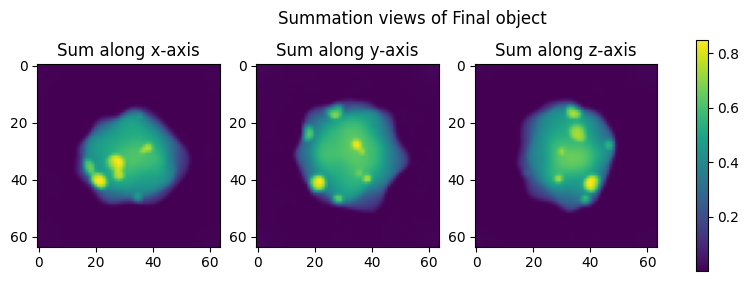

In [28]:
plotter.plot_sum_object(save_name="Final object")

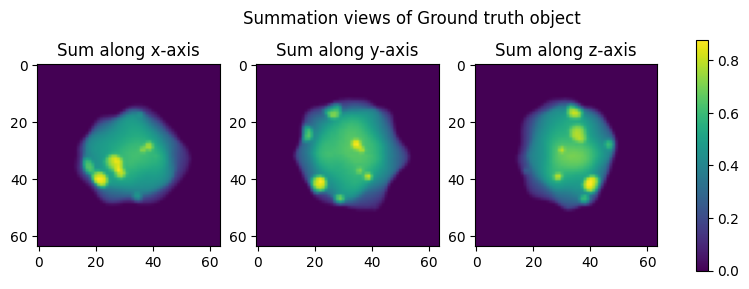

In [29]:
plotter.plot_sum_object(obj=test_object.cpu(), save_name="Ground truth object")

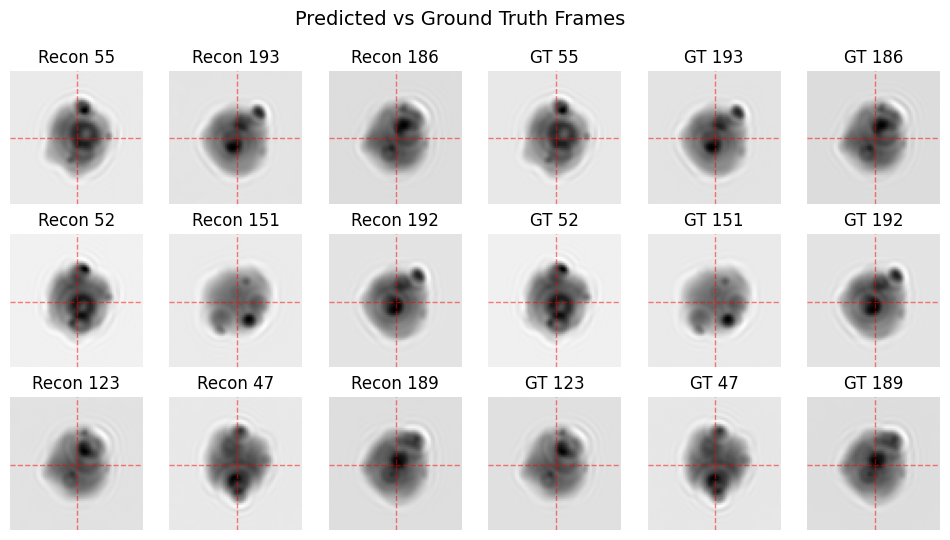

In [30]:
plotter.plot_reconstructed_vs_gt(column_headers=["Predicted", "Ground Truth"], forward=True, save_name="Reconstructed vs GT")

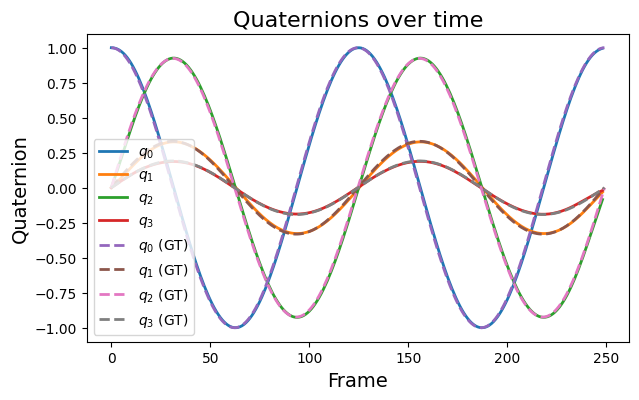

In [31]:
plotter.plot_quaternions(q_gt=q_gt)

The most effective way to visualize and compare the reconstructed volume to the ground truth is through interactive 3D plots using `plotly`.

In [32]:
# Uncomment belowto visualize the 3D volume
# tomodpdt.plotting.visualize_3d_volume(tomographic_model.volume.detach().cpu(), save_name="Final object 3D")
# tomodpdt.plotting.visualize_3d_volume(test_object.cpu(), save_name="Ground truth object 3D")

## 6. Save Result

Once the process is complete, we can save the reconstructed volume and the quaternion parameters to `numpy` arrays.

In [33]:
# Define where to save the reconstruction results
# save_folder = "path/to/save/folder"

# --- Save the reconstructed 3D volume ---
# Extract the optimized volume from the model and save as a NumPy array
# volume = tomographic_model.get_volume().detach().cpu().numpy()
# np.save(f"{save_folder}/volume.npy", volume)

# --- Save the optimized quaternions ---
# Extract the final quaternion parameters and save them as a NumPy array
# quaternions_pred = tomographic_model.get_quaternions_final().detach().cpu().numpy()
# np.save(f"{save_folder}/quaternions.npy", quaternions_pred)

